# Incorporating Reference Dependence (i.e., a Desperation Threshold) into Decision-making under Uncertainty

By Brendan Lam

Economic models of decision-making traditionally assume rational and consistent decision-making. Developments in both Prospect Theory (Kahneman & Tversky, 1997) and insights from ecologists (e.g., Stephens 1982) built "thresholds" or "inflection points" in their models of decision-making to reflect people's changing valuations  under different contexts. I will use these ideas to modify and potentially improve decision-making models under ambiguity, in which there are no thresholds in the previous literature that account for changes in one's economic standing. More specifically, I will use the concept of reference dependence, which is when people are more sensitive to potential losses than gains (Kahneman & Tversky, 1997). The value function is concave for gains, convex for losses, and steeper for losses than gains, indicating loss aversion.

Unlike Prospect Theory, the proposed model does not use gains and losses as reference points. Instead, it introduces a threshold figure representing a state of debt (negative resources). This threshold influences ambiguity attitudes, making individuals more ambiguity-seeking when below this threshold (in debt) and ambiguity-averse when above it (positive resources).

### Model Development

1. We define a threshold that is located at 0. Above the threshold represents having money and/or resources and  below the threshold represents being in a deficit/having debt. Note that the current definition represents __absolute__ deprivation. To represent relative deprivation, we can define the threshold as one that is below the resource levels of those around them (e.g., using a Gini coefficient). 

2. __Value Function Adjustment__. We change the function of our utility function $SV(x,\psi, p)$, where $x$ represents the number of resources, $p$ is the probability of an event occurring, and $\psi$ is a vector of parameters that represent the psychological processes in an agent's decision-making. 

$$
SV(x, p, \psi) = U(x) exp(\beta(-ln(p)^{\alpha})
$$

We can modify the utility function so that it changes according to the level of resources:

$$
U(x) \left\{ \begin{aligned} 
& x^\gamma \;if\; x > 0 \\
& x^\gamma + \lambda(-x) \;if\; x < 0 \\
\end{aligned} \right.
$$

where $\lambda$ represents the heightened sensitivity to wealth under desperation.



We present a graph of the desperation thershold  below.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

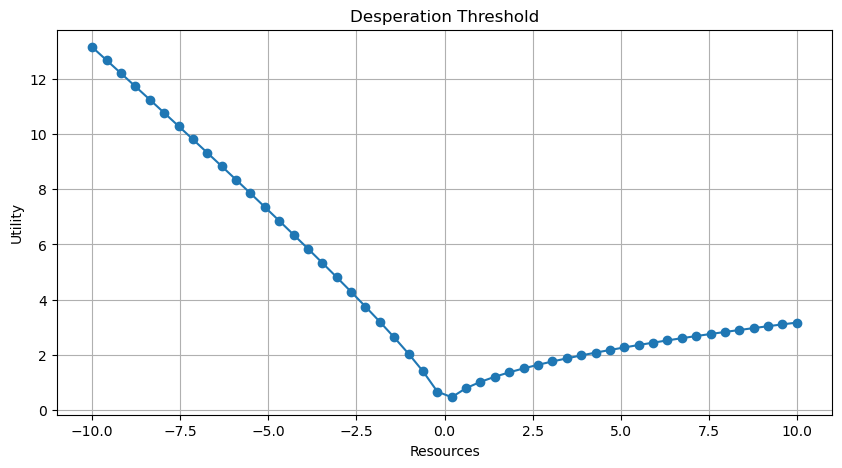

In [3]:
xs = np.linspace(-10,10)

def utility_desperation(X, gamma, lambd):
    utils = np.zeros(len(X))
    for x in range(len(X)):
        if X[x] < 0:
            utils[x] = (np.abs(X[x])**gamma) + (lambd * np.negative(X[x]))
        else:
            utils[x] = np.abs(X[x])**gamma
    return utils

modif_utils = utility_desperation(X=xs, gamma=0.5, lambd=1)

# plot results
plt.figure(figsize=(10, 5))
plt.plot(xs, modif_utils, marker='o')
plt.title('Desperation Threshold')
plt.xlabel('Resources')
plt.ylabel('Utility')
plt.grid()


Furthermore, we present code in which the depseration threshold is combined with a probability weighting function to determine the subjective value of a choice.

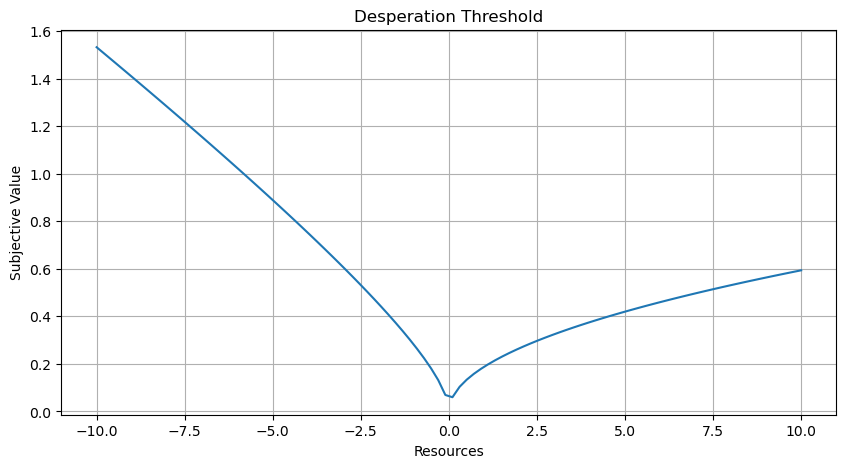

In [6]:
# Probability weighting function (Prelec, 1998)
def prelec_prob_weight(p, alpha, beta):
    w_p = np.exp(-beta*(-np.log(p))**alpha)
    return w_p

def SV(wealth, ps, alpha, beta, gamma, lambd):
    SVs = np.zeros(len(wealth))
    util = np.zeros(len(wealth))
    w_p = np.zeros(len(wealth))
    util = utility_desperation(wealth, gamma, lambd)
    for i in range(len(wealth)):
        w_p[i] = prelec_prob_weight(ps[i], alpha, beta)
        SVs[i] = util[i]*w_p[i]

    return SVs

# Generate data
wealth = np.linspace(-10,10,100)
ps = np.full(len(wealth), 0.5)
svs = SV(wealth=wealth, ps = ps, alpha=0.2, beta=1.8, gamma=0.5, lambd=0.5)

# Plot figure
plt.figure(figsize=(10,5))
plt.plot(wealth, svs)
plt.title('Desperation Threshold')
plt.xlabel('Resources')
plt.ylabel('Subjective Value')
plt.grid()

# Relative Deprivation

The above definition refers to an **absolute** threshold. An absolute threshold is the same for all individuals and it can be objectively defined as some benchmark (e.g., the poverty line in the U.S being ~$14k, being in debt). Absolute thresholds are useful and have been tested in several models. We seek to build on that previous literature by adding a relative deprivation threshold.

A relative deprivation threshold is theorized to vary across individuals, in which they compare their own standing/fitness to those around them. Mishra et al. (2015) posit that social comparison likely explains many risky and antisocial behaviors when a person's survival is not at stake. In their dual pathways model, they state that there is a "Need-based" pathway and an "Ability-based" pathway to decision-making under uncertainty. The Need-based is based on risk-sensitivity theory (Stephen, 1982) and refers to the absolute deprivation in which an organism falls below a threshold for survival, and must make an uncertain decision to have a chance at survival. The ability-based pathway refers to the social and personal capital a person stands to gain from their uncertain decision. Making an uncertain choice can signal to others that you can afford to lose resources, which conveys higher status. Moreover, the "ability" to take uncertain decisions also refers to the cushion or stability a person has, which enables them to take the chance. 

Our model seeks to model relative deprivation, given that it likely reflects the pathway behind much of non-violent crime in American society. 

### Modeling relative deprivation

To model relative deprivation, we can modify the absolute deprivation threshold above to vary across individuals, and for the threshold to be determined by the resources of the people around them. 

1. To receive less than one wants (desires, needs) results in a sense of deprivation; 2. to receive less than one expects results in feelings of disappointment; 3. to receive less than is mandated by accepted social rules and values (that to which one is entitled) results in a  sense of injustice.

Testing three different measures of relative deprivation, Gero et al. (2022) found that income rank was comparable to a CR index by Hounkpatin et al. (2020), both of which performed better than the popular Yitzhaki index of relative deprivation. Although  income rank does not account for the magnitude of difference between a person and those around them, it is parsomonious, easy to understand and found to perform comparably to the CR index in predicting physical and mental health outcomes. Thus, we will use the income rank to determine one's desperation threshold. We will also use the CR index in our sensitivity analyses to see if the results differ.

$$
Income \ rank_i = \frac{i - 1}{n - 1}
$$

Where $i - 1$ represents the number of people lower than individual $i$'s income and $n - 1$ represents the number of people in the individual's reference group. 

In [21]:
def income_rank(i,n):
    """
    Calculate the income rank of individual i in a reference group of size n.
    """
    return (i - 1) / (n - 1)

In [23]:
income_rank(1,20)

0.0

# Supplementary material

The CR index from Hounkpatin et al. (2020) calculates relative deprivation through the following:

$$
CR_i = \frac{\sum_{k=i+1}^{k=n}(y_k - y_i)^\alpha}{(n-1)}
$$

Where $y_i$ is respondent $i$’s income, $y_i$ is the earnings of respondent $k$ whose income is higher than individual $i$’s, $\alpha$ is a weighting parameter, and $n$ is the total number of respondents in $i$’s reference group.

In [ ]:
def cr_index(y_k, y_i, alpha, n):
    return (np.sum((y_k - y_i)^alpha) / (n - 1) # Example CR index, can be replaced with actual formula